In [7]:
df_raw = pd.read_csv(
    'btcusd_1-min_data.csv',
    names=['Timestamp', 'Open', 'High', 'Low', 'Close',
           'Volume_BTC', 'Volume_USD', 'Weighted_Price']
)
print(df_raw.shape)
print(df_raw.head())
print(df_raw['Timestamp'].dtype)

(7451681, 8)
      Timestamp  Open  High   Low  Close Volume_BTC  Volume_USD  \
0     Timestamp  Open  High   Low  Close     Volume         NaN   
1  1325412060.0  4.58  4.58  4.58   4.58        0.0         NaN   
2  1325412120.0  4.58  4.58  4.58   4.58        0.0         NaN   
3  1325412180.0  4.58  4.58  4.58   4.58        0.0         NaN   
4  1325412240.0  4.58  4.58  4.58   4.58        0.0         NaN   

   Weighted_Price  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  
object


Shape: (100000, 5)
Date range: 2025-12-24 13:21:00  →  2026-03-04 00:00:00


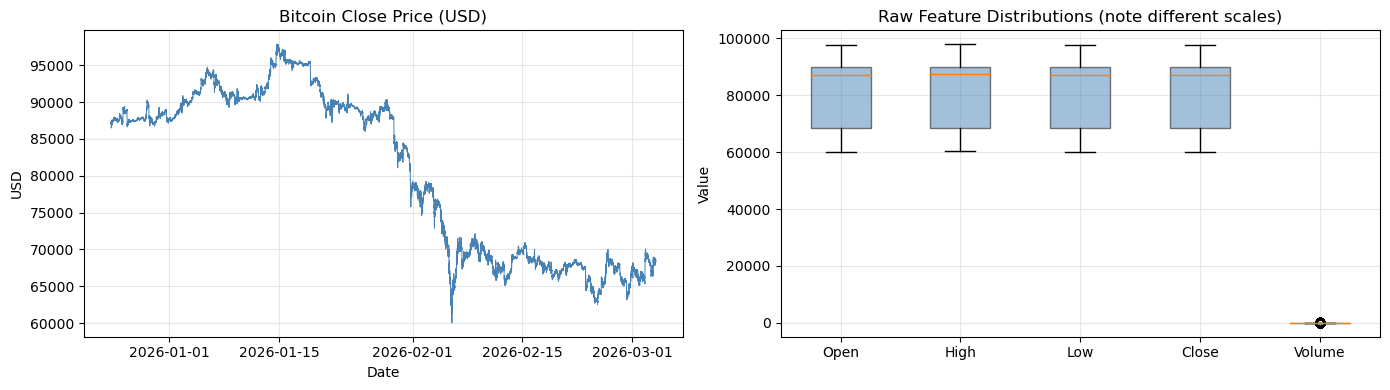

Mean after standardization (should be ~0):
[ 0. -0.  0. -0. -0.]

Std after standardization (should be ~1):
[1. 1. 1. 1. 1.]


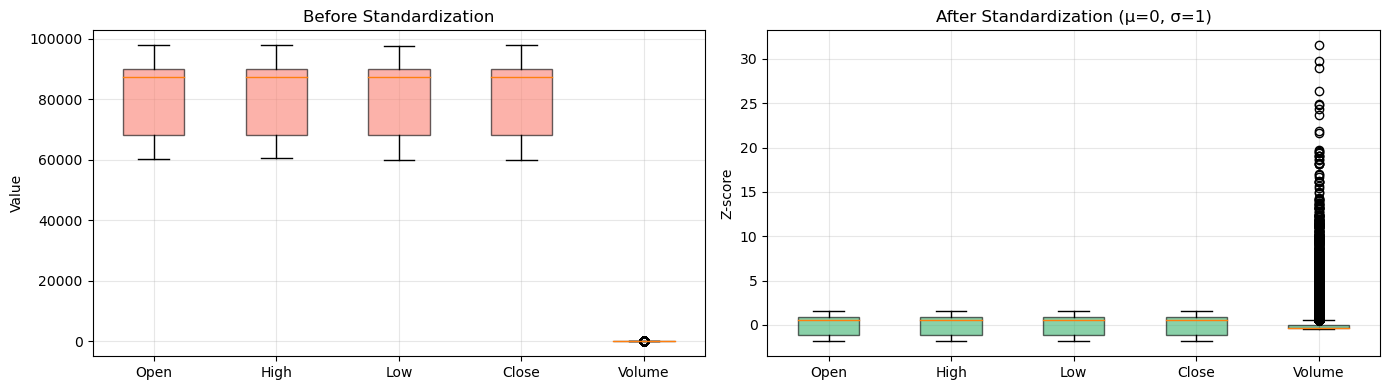

Covariance BEFORE sphering:


,Open,High,Low,Close,Volume
Open,1.000,1.000,1.000,1.000,-0.147
High,1.000,1.000,1.000,1.000,-0.146
Low,1.000,1.000,1.000,1.000,-0.149
Close,1.000,1.000,1.000,1.000,-0.147
Volume,-0.147,-0.146,-0.149,-0.147,1.000



Covariance AFTER sphering (should be ~Identity):


,Open,High,Low,Close,Volume
Open,1.0,-0.0,-0.0,0.0,0.0
High,-0.0,1.0,0.0,-0.0,-0.0
Low,-0.0,0.0,1.0,-0.0,-0.0
Close,0.0,-0.0,-0.0,1.0,0.0
Volume,0.0,-0.0,-0.0,0.0,1.0


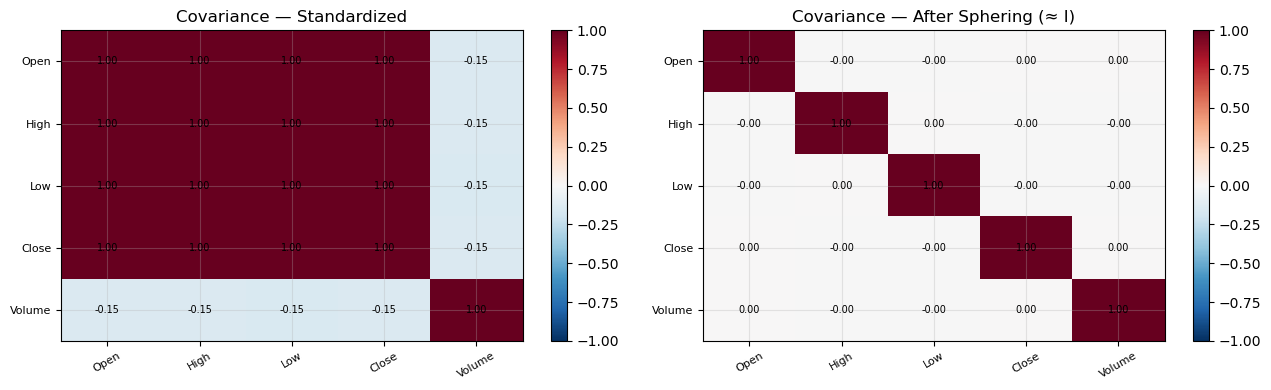

PC1: 80.57%  (cumulative: 80.57%)
PC2: 19.43%  (cumulative: 100.00%)
PC3: 0.00%  (cumulative: 100.00%)
PC4: 0.00%  (cumulative: 100.00%)
PC5: 0.00%  (cumulative: 100.00%)

Loadings:


,PC1,PC2,PC3,PC4,PC5
Open,0.498,0.048,0.717,0.049,0.483
High,0.498,0.050,-0.067,0.711,-0.490
Low,0.498,0.047,0.042,-0.699,-0.509
Close,0.498,0.048,-0.692,-0.061,0.517
Volume,-0.097,0.995,0.000,-0.002,-0.000


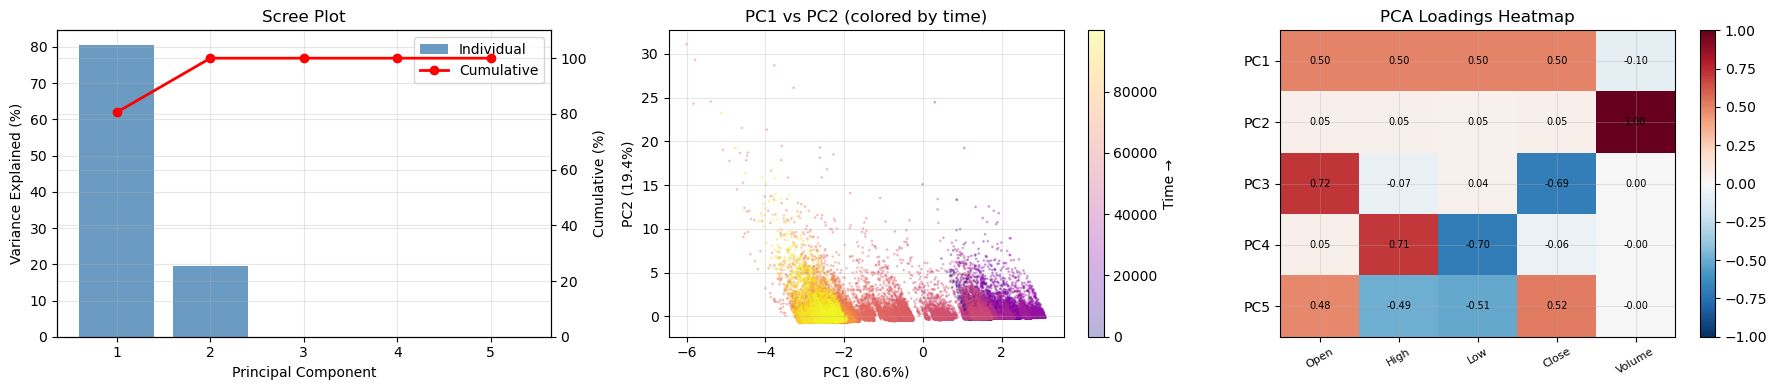

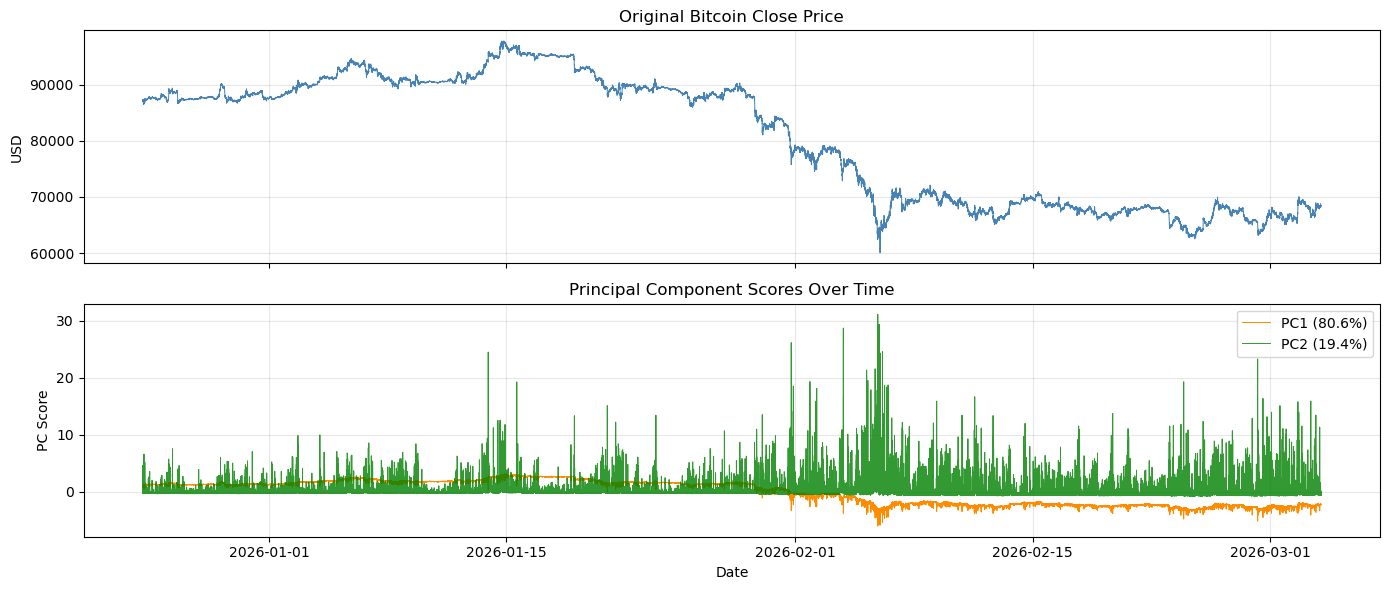

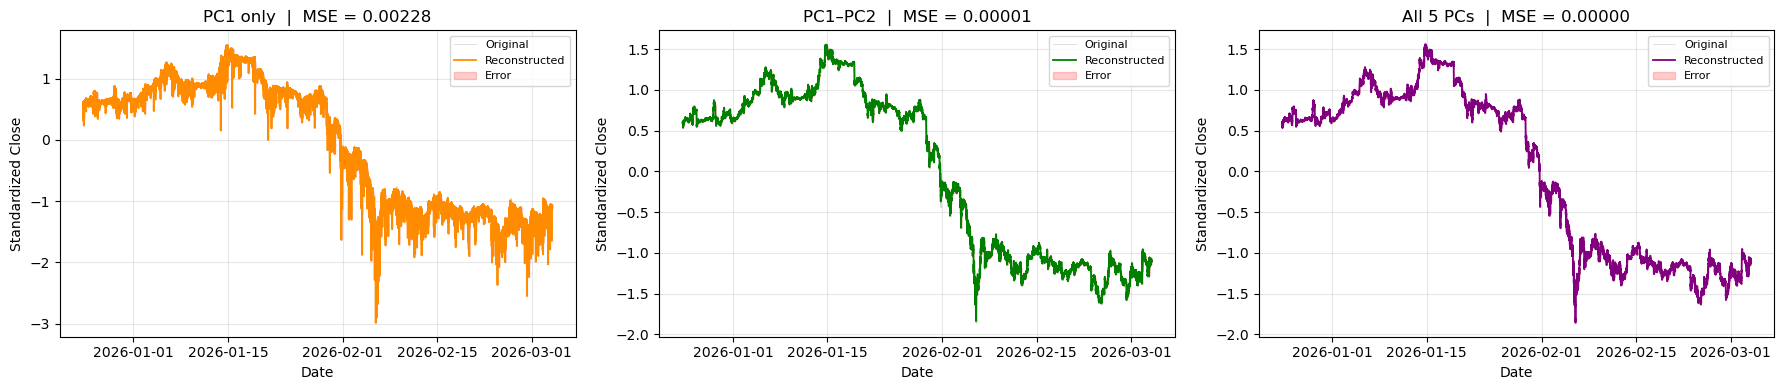

In [9]:
#import the necessary libraries for maths table graphs standardizationn and pca
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings


warnings.filterwarnings('ignore') #ignores unneccesary warnings that disrupt the process

#sets the size of graphs and puts a grid and sets it transparency for the graphs that will be plotted
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Load Dataset
df_raw = pd.read_csv('btcusd_1-min_data.csv') #read csv put raw folder to dfraw
df = df_raw.dropna().copy() #deletes missing values and create a new copy to prevent error
df = df[df['Timestamp'] != 'Timestamp'] #remove reccuring headers
df['Timestamp'] = pd.to_datetime(df['Timestamp'].astype(float), unit='s')#turn timestamp into float then real date unix
df = df.set_index('Timestamp').sort_index()#make the date index and sort chronologicaly

#Turn collumns into numerical value if not NaN
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna().iloc[-100_000:]#

#print out the size of dataset and print the first and last date
print(f"Shape: {df.shape}")
print(f"Date range: {df.index[0]}  →  {df.index[-1]}")

# ── Raw Data Exploration ──────────────────────────────────────────────────────

#set the collumn names in a list ad sets their values to numPy
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X_raw = df[features].values


fig, axes = plt.subplots(1, 2, figsize=(14, 4)) #creates grafic area of 1 to 2
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=0.7) #draw btc close graphic line moving along time axis
axes[0].set_title('Bitcoin Close Price (USD)') #sets graphic header
#xy axis headers
axes[0].set_xlabel('Date')
axes[0].set_ylabel('USD')

#boxplot of raw data in graph
axes[1].boxplot(X_raw, labels=features, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))

#sets header and y axis header of the second graph, sets the spaces and plots the graph
axes[1].set_title('Raw Feature Distributions (note different scales)')
axes[1].set_ylabel('Value')
plt.tight_layout()
plt.show()

# ── Standardization ───────────────────────────────────────────────────────────
scaler = StandardScaler() #scaler object setted
X_std = scaler.fit_transform(X_raw) #standardize the raw data

#print out means and Standard deviation after standardiation 
print("Mean after standardization (should be ~0):")
print(np.round(X_std.mean(axis=0), 6))
print("\nStd after standardization (should be ~1):")
print(np.round(X_std.std(axis=0), 6))


fig, axes = plt.subplots(1, 2, figsize=(14, 4))#1 to 2 graph area to setted for comparison

#boxplotting raw data, left side
axes[0].boxplot(X_raw, labels=features, patch_artist=True,
                boxprops=dict(facecolor='salmon', alpha=0.6))
#header setting, left side
axes[0].set_title('Before Standardization')
axes[0].set_ylabel('Value')

#boxplotting standardized data, right side
axes[1].boxplot(X_std, labels=features, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.6))

#header setting, right side
axes[1].set_title('After Standardization (μ=0, σ=1)')
axes[1].set_ylabel('Z-score')

#plot the graphs
plt.tight_layout()
plt.show()

# ── Sphering (Whitening) ──────────────────────────────────────────────────────
cov_std = np.cov(X_std.T) # Calculate the covariance matrix(how much the features move together) of standardized data
eigenvalues, eigenvectors = np.linalg.eigh(cov_std) # Calculate the eigenvalues(variance magnitude) and eigenvectors(variance direction) of covariance matrix
W = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T # Create the whitening transformation matrix using linear algebra
X_white = X_std @ W.T #Apply the whitening matrix to the standardized data
cov_white = np.cov(X_white.T) # Calculate the covariance matrix of NEW whitened data

# Display the covariance matrix before sphering (high numbers = high correlation)
print("Covariance BEFORE sphering:")
display(pd.DataFrame(cov_std, index=features, columns=features).round(3))

# Display the covariance matrix after sphering (should look like an Identity matrix: 1s on diagonal, 0s elsewhere)
print("\nCovariance AFTER sphering (should be ~Identity):")
display(pd.DataFrame(cov_white, index=features, columns=features).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4)) #create 1x2 grid to plot heatmap of covariance matrices

#loop through both matrices to generate heatmaps side-side
for ax, cov, title in zip(axes,
                           [cov_std, cov_white],
                           ['Covariance — Standardized',
                            'Covariance — After Sphering (≈ I)']):
    
    #draw heatmap grid set colours
    im = ax.imshow(cov, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(title)
    
    #set xy axis labels
    ax.set_xticks(range(5)); ax.set_xticklabels(features, rotation=30, fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(features, fontsize=8)
    
    #loop through every cell in matrix write exact numbers in the square
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cov[i,j]:.2f}', ha='center', va='center', fontsize=7)
            
    plt.colorbar(im, ax=ax) #add colour legend of heatmap
    
#plot the graph map
plt.tight_layout()
plt.show()

# ── PCA ───────────────────────────────────────────────────────────────────────


pca = PCA(n_components=5) # Initialize PCA to extract 5 components (since we have 5 features)
X_pca = pca.fit_transform(X_std) # Fit the PCA algorithm to the standardized data and transform it into Principal Components(PC's)
explained = pca.explained_variance_ratio_ # Gets percentage of data variance explained by each component
cumulative = np.cumsum(explained) # Calculates the cumulative sum of variance explained

# Prints how much variance PC's explain
for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1}: {ev*100:.2f}%  (cumulative: {cum*100:.2f}%)")

# Creates a Dataframe showing "Loadings" (how much each original feature contributes to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(5)]
)
#prints loadings from dataset
print("\nLoadings:")
display(loadings.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4)) #1x3 grid for PCA visualization

# GRAPH 1: Scree Plot (Bar chart showing variance explained by each PC)
axes[0].bar(range(1, 6), explained * 100, color='steelblue', alpha=0.8, label='Individual')#generates bars of variance percentages of each component
ax0b = axes[0].twinx() #creates second y axis for cumulative line
ax0b.plot(range(1, 6), cumulative * 100, 'ro-', linewidth=2, label='Cumulative') #plots the cumulative line

#label and axis setting
ax0b.set_ylim(0, 110)
ax0b.set_ylabel('Cumulative (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')

# Combine legends for both the bars and the line
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax0b.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2)


# GRAPH 2: Scatter plot of PC1 vs PC2 (colored by how much time has passed)
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=np.arange(len(X_pca)), cmap='plasma', alpha=0.3, s=1)

#Graph and axis headers setting
axes[1].set_title('PC1 vs PC2 (colored by time)')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
plt.colorbar(sc, ax=axes[1], label='Time →') #Colour scale representing timeframe


# GRAPH 3: Heatmap of the PCA Loadings (which features dominate which PC)
im = axes[2].imshow(pca.components_, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1) #setting tick locations x axis and labeling them with features

axes[2].set_title('PCA Loadings Heatmap') #header of graph
axes[2].set_xticks(range(5)); axes[2].set_xticklabels(features, rotation=30, fontsize=8) #setting tick locations x axis and labeling them with features
axes[2].set_yticks(range(5)); axes[2].set_yticklabels([f'PC{i+1}' for i in range(5)])#setting tick locations y axis and labeling them with PC names

# Write the exact loading values inside the heatmap squares
for i in range(5):
    for j in range(5):
        axes[2].text(j, i, f'{pca.components_[i,j]:.2f}',
                     ha='center', va='center', fontsize=7)
        
plt.colorbar(im, ax=axes[2])#colorbar for graph3

#set and plot the graph
plt.tight_layout()
plt.show()

# ── PC Time Series ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True) # Plot the Original close price vs. the movement of PC1 and PC2 over time

# TOP GRAPH: Original Price Graph, title axis setting
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=0.7)
axes[0].set_title('Original Bitcoin Close Price')
axes[0].set_ylabel('USD')

# BOTTOM GRAPH: PC1 and PC2 moving through time
axes[1].plot(df.index, X_pca[:, 0], color='darkorange', linewidth=0.7,
             label=f'PC1 ({explained[0]*100:.1f}%)')
axes[1].plot(df.index, X_pca[:, 1], color='green', linewidth=0.7, alpha=0.8,
             label=f'PC2 ({explained[1]*100:.1f}%)')

#bottom graphs title xy axis legend
axes[1].set_title('Principal Component Scores Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('PC Score')
axes[1].legend()

#plot set and show
plt.tight_layout()
plt.show()

# ── Reconstruction ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4)) #1 to 3 graphic area

# Get the standardized version of the "Close" price specifically (index 3 of our features)
close_std = (df['Close'].values - scaler.mean_[3]) / scaler.scale_[3] 

# Loop through testing a reconstruction using 1 PC, 2 PCs, and all 5 PCs
for ax, n, col in zip(axes, [1, 2, 5], ['darkorange', 'green', 'purple']):
    X_approx = X_pca.copy() # Make a copy of the PCA data
    X_approx[:, n:] = 0 #Zero out the components we ARE NOT using for this specific test
    X_rec = pca.inverse_transform(X_approx) # Reverse the PCA math to turn the Principal Components back into standardized features
    close_rec = X_rec[:, 3] # Extract just the reconstructed "Close"
    mse = np.mean((close_std - close_rec) ** 2) # Calculate Mean Squared Error (MSE) (how wrong the reconstruction is compared to reality)
    ax.plot(df.index, close_std, color='lightgray', linewidth=0.5, label='Original', zorder=1) # Plot the Original Standardized Close Price
    ax.plot(df.index, close_rec, color=col, linewidth=1.3, label='Reconstructed', zorder=2) # Plot the newly Reconstructed Close Price over
    
    # Shade the area between the two lines to visualize the error/difference
    ax.fill_between(df.index, close_std, close_rec,
                    alpha=0.2, color='red', zorder=0, label='Error')
    
    # Sets header based on how many PCs were used, axis and legend
    label = 'PC1 only' if n == 1 else f'PC1–PC{n}' if n < 5 else 'All 5 PCs'
    ax.set_title(f'{label}  |  MSE = {mse:.5f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Standardized Close')
    ax.legend(fontsize=8)
    
#set and plot
plt.tight_layout()
plt.show()